<h1 align=center style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
از دید ناحیه
</font>
</h1>

<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
مقدمه
</font>
</h2>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
در این تمرین قصد داریم تا با استفاده از قطعه‌بندی مبتنی بر ناحیه، قطعه‌بندی را انجام دهیم.
</font>
</p>

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

<h3 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
مرحله اول: وارد کردن تصویر
</font>
</h3>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
ابتدا تصویر زیر را بصورت خاکستری بخوانید.
<br>
brain.webp
</font>
</p>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
همچنین در صورتیکه نیاز به اعمال پیش‌پردازش میباشد آنرا نیز در این مرحله انجام دهید.
</p>


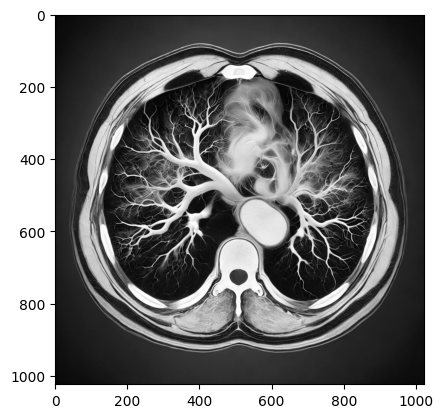

In [2]:
img = cv2.imread('./Data/brain.webp', cv2.IMREAD_GRAYSCALE)
plt.imshow(img, cmap='gray')

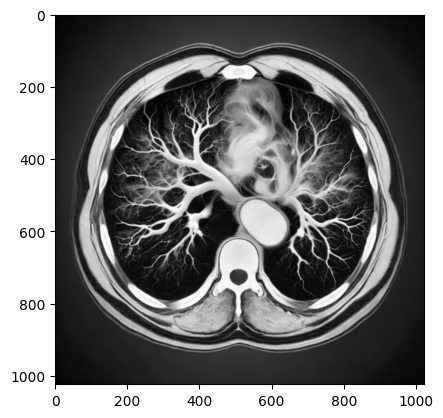

In [3]:
blur = cv2.GaussianBlur(img, (5, 5), 0)
plt.imshow(blur, cmap='gray')


<h3 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
مرحله دوم: پیاده‌سازی گسترش ناحیه
</font>
</h3>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
برای قطعه‌بندی ما از رویکرد گسترش‌ناحیه یا Region Growing استفاده می‌کنیم. شما باید آنرا پیاده‌سازی کنید.
    <br>
    پس از پیاده‌سازی و انجام قطعه‌بندی، باید تصویر قطعه‌بندی شده را ذخیره کنید. توجه کنید که پیش‌زمینه حتما سیاه باشد و پس‌زمینه حتما سفید باشد. تصویر را به نام زیر ذخیره کنید:
    <br>
    region_segment.jpg
</font>
</p>

In [4]:
seed = (100, 100)          # (x, y)
thresholds = [50, 100, 150, 200]

h, w = blur.shape

# همسایگی ۸تایی
neighbors = [(-1,0),(1,0),(0,-1),(0,1),
             (-1,-1),(-1,1),(1,-1),(1,1)]


# ---------- تابع Region Growing ----------
def region_growing(image, seed, T):
    h, w = image.shape

    seed_val = int(image[seed[1], seed[0]])

    mask = np.zeros((h, w), dtype=np.uint8)
    visited = np.zeros((h, w), dtype=np.uint8)

    stack = [seed]

    while stack:
        x, y = stack.pop()

        if visited[y, x]:
            continue

        visited[y, x] = 1

        # معیار همگنی
        if abs(int(image[y, x]) - seed_val) < T:
            mask[y, x] = 255

            for dx, dy in neighbors:
                nx, ny = x + dx, y + dy
                if 0 <= nx < w and 0 <= ny < h:
                    if not visited[ny, nx]:
                        stack.append((nx, ny))

    return mask


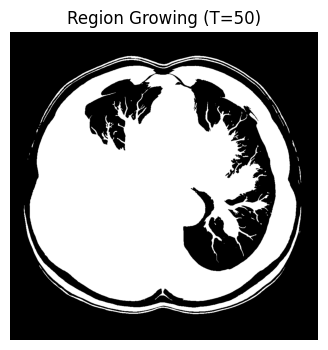

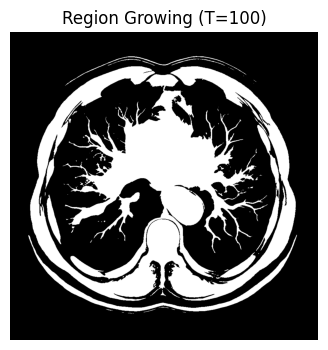

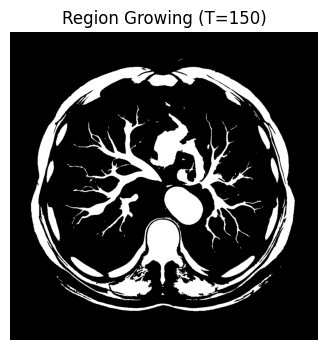

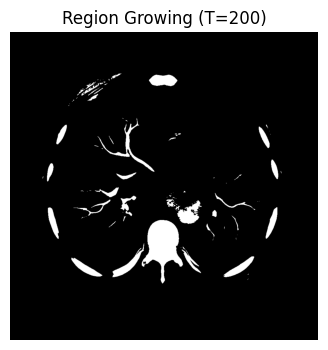

In [8]:
for T in thresholds:
    mask = region_growing(blur, seed, T)
    mask = 255 - mask
    plt.figure(figsize=(4,4))
    plt.imshow(mask, cmap="gray")
    plt.title(f"Region Growing (T={T})")
    plt.axis("off")
    plt.show()

In [9]:
mask = region_growing(blur, seed, 100)
mask = 255 - mask
cv2.imwrite('region_segment.jpg', mask)

True

<h3 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
مرحله سوم: سلول جواب‌ساز
</font>
</h3>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
بدون هیچگونه تغییری، این سلول را اجرا کنید تا فایل پاسخ شما آماده شود.
</font>
</p>

In [10]:
import zipfile

def compress(file_names):
    print("File Paths:")
    print(file_names)
    # Select the compression mode ZIP_DEFLATED for compression
    # or zipfile.ZIP_STORED to just store the file
    compression = zipfile.ZIP_DEFLATED
    # create the zip file first parameter path/name, second mode
    with zipfile.ZipFile("result.zip", mode="w") as zf:
        for file_name in file_names:
            # Add file to the zip file
            # first parameter file to zip, second filename in zip
            zf.write('./' + file_name, file_name, compress_type=compression)


file_names = ["notebook.ipynb", "region_segment.jpg"]
compress(file_names)

File Paths:
['notebook.ipynb', 'region_segment.jpg']
